In [1]:
import pandas as pd

# Load the DataFrame
df = pd.read_csv('/Users/ds39/Documents/Sunny/MAVE/RD/concentration/250402_AllTargetonlist_quantification_revalues.csv')

# Compute the average mapped reads and add it as a new column
df['average_Mapped_reads'] = (df['D4R1 Mapped Reads'] + 
                              df['D4R2 Mapped Reads'] + 
                              df['D4R3 Mapped Reads']) / 3

# Step 1: Filter the DataFrame to only keep rows with 'Pass' or 'Fail' in the original 'Analysis Status'
filtered_df = df[df['Analysis Status'].isin(['Pass', 'Fail'])].copy()

# New Step: Update 'Analysis Status' based on 'average_Mapped_reads'
# If average mapped reads is above 40, set as 'Pass'; otherwise, set as 'Fail'
filtered_df.loc[filtered_df['average_Mapped_reads'] > 40, 'Analysis Status'] = 'Pass'
filtered_df.loc[filtered_df['average_Mapped_reads'] <= 40, 'Analysis Status'] = 'Fail'

# Step 2: Replace 'Pass' with 0 and 'Fail' with 1
filtered_df['Analysis Status'] = filtered_df['Analysis Status'].replace({'Pass': 0, 'Fail': 1})

# Step 3: Remove rows with missing values or non-numeric entries in all numeric columns
numeric_columns = filtered_df.select_dtypes(include=['number']).columns
filtered_df = filtered_df.dropna(subset=numeric_columns)

# Print the final filtered DataFrame to verify changes
print(filtered_df.head())


  Targeton Name   Gene Hdr Vector Lot  Nanodrop (ng/ul)  A260/A280  A260/A230  \
2          AXFG  SMC1A    AXFG_hdr500            4360.0      1.948      2.563   
4          BBAI   CTCF    BBAI_hdr412             929.8      1.912      2.342   
5          BCWL  DDX23    BCWL_hdr483             827.6      2.003      2.755   
6          BPAV  POLD1    BPAV_hdr610            1125.6      1.997      2.650   
7          BUKA   CTCF    BUKA_hdr484            2508.1      1.910      2.434   

   Qubit Re-quant (ng/ul)  Actual_ug_into_cells  gRNA Vector Lot  \
2                     246              0.846330  AXFG_gRNAvec581   
4                     615              9.921488  BBAI_gRNAvec307   
5                     252              4.567424  BCWL_gRNAvec022   
6                     264              3.518124  BPAV_gRNAvec034   
7                     650              3.887405  BUKA_gRNAvec635   

   Nanodrop (ng/ul).1  ...  Qubit Re-quant (ng/ul).1  Actual_ug_into_cells.1  \
2              917.75  .

/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_28246/2599337007.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_df['Analysis Status'] = filtered_df['Analysis Status'].replace({'Pass': 0, 'Fail': 1})


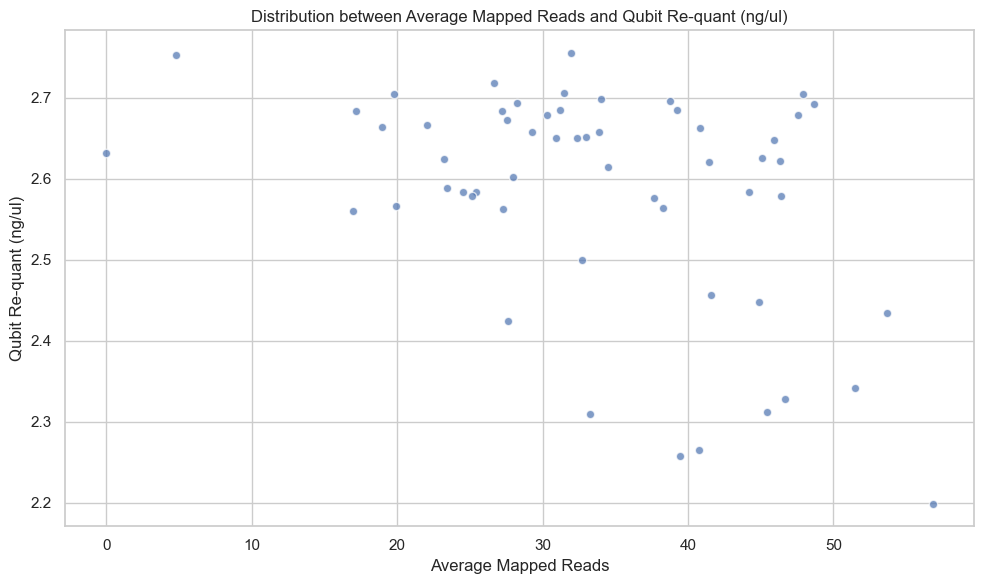

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df['average_Mapped_reads'], filtered_df['A260/A230'], 
            alpha=0.7, edgecolor='w')
plt.title("Distribution between Average Mapped Reads and Qubit Re-quant (ng/ul)")
plt.xlabel("Average Mapped Reads")
plt.ylabel("Qubit Re-quant (ng/ul)")
plt.grid(True)
plt.tight_layout()
plt.show()


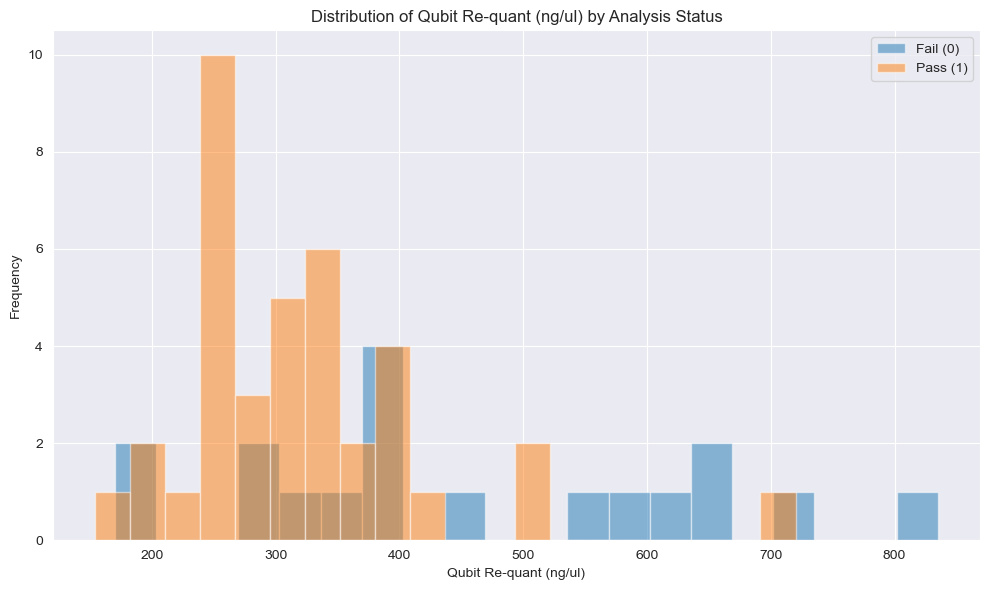

In [3]:
import matplotlib.pyplot as plt

# Separate the data based on Analysis Status
fail_group = filtered_df[filtered_df['Analysis Status'] == 0]['Qubit Re-quant (ng/ul)']
pass_group = filtered_df[filtered_df['Analysis Status'] == 1]['Qubit Re-quant (ng/ul)']

plt.figure(figsize=(10, 6))

# Plot histograms for each group
plt.hist(fail_group, bins=20, alpha=0.5, label='Fail (0)')
plt.hist(pass_group, bins=20, alpha=0.5, label='Pass (1)')

plt.title('Distribution of Qubit Re-quant (ng/ul) by Analysis Status')
plt.xlabel('Qubit Re-quant (ng/ul)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


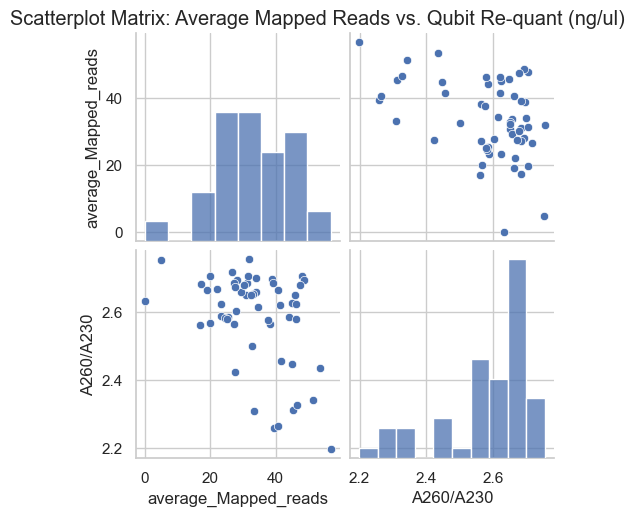

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the scatterplot matrix
plot_data = filtered_df[['average_Mapped_reads', 'A260/A230']]

# Create a pairplot (scatter matrix) for the selected columns
sns.pairplot(plot_data, kind='scatter', diag_kind='hist')

plt.suptitle("Scatterplot Matrix: Average Mapped Reads vs. Qubit Re-quant (ng/ul)", y=1.02)
plt.show()
